In [2]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Activation, Dropout, Flatten, Dense, Input, Layer
from tensorflow.keras.layers import Embedding, LSTM, add, Concatenate, Reshape, concatenate, Bidirectional
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet201
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
from textwrap import wrap
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
plt.rcParams['font.size'] = 12

In [3]:
image_path = '/LAB/Image Captioning/flickr8k_Dataset/Images'
data = pd.read_csv("/LAB/Image Captioning/flickr8k_Dataset/captions.txt")
data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [5]:
def readImage(path,img_size=224):
    img = load_img(path,color_mode='rgb',target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.
    
    return img

def display_images(temp_df):
    temp_df = temp_df.reset_index(drop=True)
    plt.figure(figsize = (20 , 20))
    n = 0
    for i in range(15):
        n+=1
        plt.subplot(5 , 5, n)
        plt.subplots_adjust(hspace = 0.7, wspace = 0.3)
        image = readImage(f"/LAB/Image Captioning/flickr8k_Dataset/Images/{temp_df.image[i]}")
        plt.imshow(image)
        plt.title("\n".join(wrap(temp_df.caption[i], 20)))
        plt.axis("off")

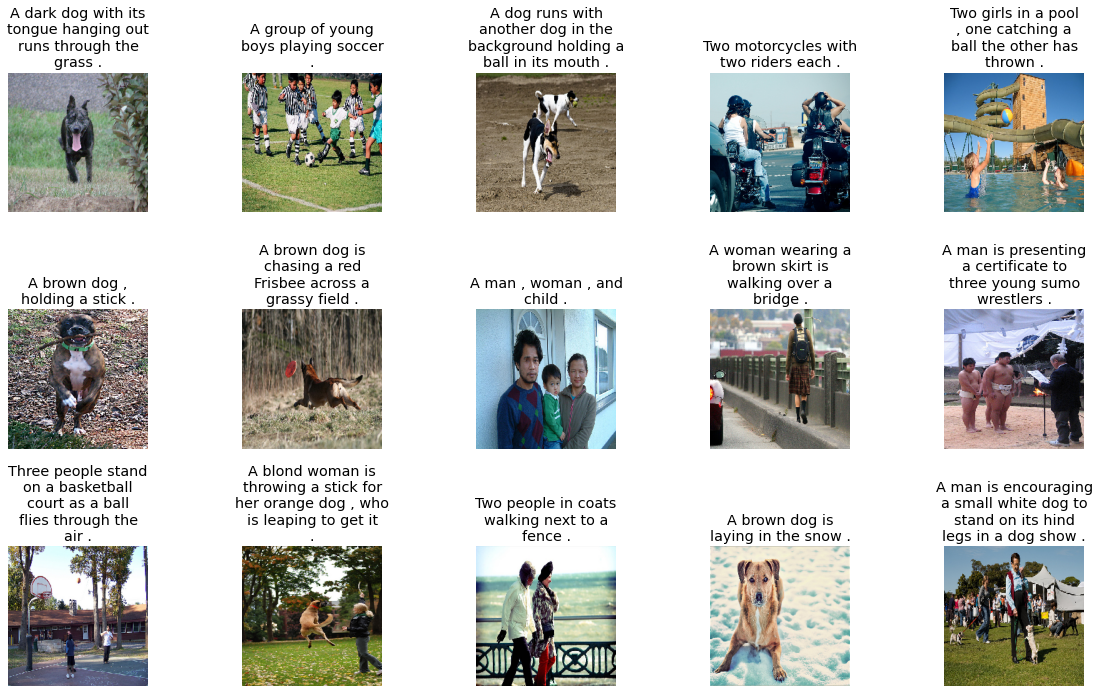

In [7]:
display_images(data.sample(15))

In [10]:
def text_preprocessing(data):
    data['caption'] = data['caption'].apply(lambda x: x.lower())
    data['caption'] = data['caption'].apply(lambda x: x.replace("[^A-Za-z]",""))
    data['caption'] = data['caption'].apply(lambda x: x.replace("\s+"," "))
    data['caption'] = data['caption'].apply(lambda x: " ".join([word for word in x.split() if len(word)>1]))
    data['caption'] = "start "+data['caption']+" end"
    return data

In [11]:
data = text_preprocessing(data)
captions = data['caption'].tolist()
captions[:10]

['start child in pink dress is climbing up set of stairs in an entry way end',
 'start girl going into wooden building end',
 'start little girl climbing into wooden playhouse end',
 'start little girl climbing the stairs to her playhouse end',
 'start little girl in pink dress going into wooden cabin end',
 'start black dog and spotted dog are fighting end',
 'start black dog and tri-colored dog playing with each other on the road end',
 'start black dog and white dog with brown spots are staring at each other in the street end',
 'start two dogs of different breeds looking at each other on the road end',
 'start two dogs on pavement moving toward each other end']

In [12]:
def idx_to_word(integer,tokenizer):
    for word, index in tokenizer.word_index.items():
        if index==integer:
            return word
    return None

In [13]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)

images = data['image'].unique().tolist()
nimages = len(images)

split_index = round(0.8*nimages)
train_images = images[:split_index]
val_images = images[split_index:]

train = data[data['image'].isin(train_images)]
test = data[data['image'].isin(val_images)]

train.reset_index(inplace=True,drop=True)
test.reset_index(inplace=True,drop=True)

tokenizer.texts_to_sequences([captions[1]])[0]

[2, 18, 315, 63, 195, 116, 1]

In [14]:
def tokenize_text(text, tokenizer):
    """ Tokenizes a given text using the Keras tokenizer. """
    sequence = tokenizer.texts_to_sequences([text.lower()])[0]
    return [idx_to_word(idx, tokenizer) for idx in sequence if idx is not None]  # Convert back to words


In [15]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os
from tqdm import tqdm

# Load the DenseNet201 model
base_model = DenseNet201(weights='imagenet', include_top=False, pooling='avg')
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

# Extract features
features = {}
image_size = 224  # Ensure it matches DenseNet201 input

for image in tqdm(data['image'].unique().tolist()):
    img = load_img(os.path.join(image_path, image), target_size=(image_size, image_size))
    img = img_to_array(img)
    img = img / 255.0  # Normalize
    img = np.expand_dims(img, axis=0)  # Add batch dimension

    feature = feature_extractor.predict(img, verbose=0)  # Extract feature
    features[image] = feature

2025-02-28 17:15:06.757416: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22118 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:3b:00.0, compute capability: 8.6
2025-02-28 17:15:06.759233: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22118 MB memory:  -> device: 1, name: NVIDIA RTX A5000, pci bus id: 0000:af:00.0, compute capability: 8.6
  0%|          | 0/8091 [00:00<?, ?it/s]2025-02-28 17:15:10.529908: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2025-02-28 17:15:13.693395: I tensorflow/stream_executor/cuda/cuda_dnn.cc:381] Loaded cuDNN version 8204
100%|██████████| 8091/8091 [08:48<00:00, 15.31it/s]


In [18]:
class CustomDataGenerator(Sequence):
    
    def __init__(self, df, X_col, y_col, batch_size, directory, tokenizer, 
                 vocab_size, max_length, features,shuffle=True):
    
        self.df = df.copy()
        self.X_col = X_col
        self.y_col = y_col
        self.directory = directory
        self.batch_size = batch_size
        self.tokenizer = tokenizer
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.features = features
        self.shuffle = shuffle
        self.n = len(self.df)
        
    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)
    
    def __len__(self):
        return self.n // self.batch_size
    
    def __getitem__(self, index):
        batch = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size,:]
        X1, X2, y = self.__get_data(batch)        
        return (X1, X2), y
    
    def __get_data(self,batch):
        
        X1, X2, y = list(), list(), list()
        
        images = batch[self.X_col].tolist()
           
        for image in images:
            feature = self.features[image][0]
            
            captions = batch.loc[batch[self.X_col]==image, self.y_col].tolist()
            for caption in captions:
                seq = self.tokenizer.texts_to_sequences([caption])[0]

                for i in range(1,len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=self.max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=self.vocab_size)[0]
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)
            
        X1, X2, y = np.array(X1), np.array(X2), np.array(y)
                
        return X1, X2, y

In [20]:
print(img.shape)

(1, 224, 224, 3)


In [21]:
from tensorflow.keras.layers import Input, Dense, Embedding, GRU, Dropout, Concatenate, Attention, RepeatVector
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Inputs
input1 = Input(shape=(1920,))  # Image feature vector
input2 = Input(shape=(max_length,))  # Tokenized caption sequence

# 🔹 Image feature processing
img_features = Dense(256, activation='relu')(input1)
img_features = RepeatVector(max_length)(img_features)  # Expand image features to match text sequence shape

# 🔹 Caption processing
sentence_features = Embedding(vocab_size, 256, mask_zero=True)(input2)

# 🔹 Merge image + text (Now their shapes match)
merged = Concatenate()([img_features, sentence_features])

# 🔹 GRU with Attention
sentence_features = GRU(256, return_sequences=True, dropout=0.3)(merged)
attention = Attention()([sentence_features, sentence_features])  # Attention applied
sentence_features = GRU(128)(attention)  # Final GRU layer

# 🔹 Fully Connected Layers
x = Dropout(0.5)(sentence_features)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# 🔹 Output Layer
output = Dense(vocab_size, activation='softmax')(x)

# 🔹 Compile Model
caption_model = Model(inputs=[input1, input2], outputs=output)
caption_model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0003), metrics=['accuracy'])

# 🔹 Learning Rate Scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

caption_model.summary()

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_4 (InputLayer)            [(None, 1920)]       0                                            
__________________________________________________________________________________________________
dense_3 (Dense)                 (None, 256)          491776      input_4[0][0]                    
__________________________________________________________________________________________________
input_5 (InputLayer)            [(None, 34)]         0                                            
__________________________________________________________________________________________________
repeat_vector_1 (RepeatVector)  (None, 34, 256)      0           dense_3[0][0]                    
____________________________________________________________________________________________

In [22]:
train_generator = CustomDataGenerator(df=train,X_col='image',y_col='caption',batch_size=64,directory=image_path,
                                      tokenizer=tokenizer,vocab_size=vocab_size,max_length=max_length,features=features)

validation_generator = CustomDataGenerator(df=test,X_col='image',y_col='caption',batch_size=64,directory=image_path,
                                      tokenizer=tokenizer,vocab_size=vocab_size,max_length=max_length,features=features)

In [23]:
model_name = "model.keras"
checkpoint = ModelCheckpoint(model_name, monitor="val_loss", mode="min", save_best_only=True, verbose=1)

earlystopping = EarlyStopping(monitor='val_loss', min_delta=0, patience=3, verbose=1, restore_best_weights=True)

learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss', patience=3, verbose=1, factor=0.5, min_lr=1e-8)


In [25]:
history = caption_model.fit(
    train_generator,
    epochs=25,
    validation_data=validation_generator,
    callbacks=[checkpoint, earlystopping, learning_rate_reduction]
)

Epoch 1/25
505/505 [==============================] - ETA: 0s - loss: 6.0007 - accuracy: 0.0983

2025-02-28 17:37:52.980946: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:689] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA RTX A5000" frequency: 1695 num_cores: 64 environment { key: "architecture" value: "8.6" } environment { key: "cuda" value: "11040" } environment { key: "cudnn" value: "8204" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 6291456 shared_memory_size_per_multiprocessor: 102400 memory_size: 23193059328 bandwidth: 768096000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


505/505 [==============================] - 192s 380ms/step - loss: 6.0007 - accuracy: 0.0983 - val_loss: 5.5149 - val_accuracy: 0.1333

Epoch 00001: val_loss improved from inf to 5.51494, saving model to model.keras
Epoch 2/25
505/505 [==============================] - 87s 172ms/step - loss: 5.3390 - accuracy: 0.1462 - val_loss: 4.9123 - val_accuracy: 0.1787

Epoch 00002: val_loss improved from 5.51494 to 4.91226, saving model to model.keras
Epoch 3/25
505/505 [==============================] - 90s 179ms/step - loss: 4.8447 - accuracy: 0.1888 - val_loss: 4.5672 - val_accuracy: 0.2085

Epoch 00003: val_loss improved from 4.91226 to 4.56718, saving model to model.keras
Epoch 4/25
505/505 [==============================] - 87s 171ms/step - loss: 4.5822 - accuracy: 0.2130 - val_loss: 4.3822 - val_accuracy: 0.2325

Epoch 00004: val_loss improved from 4.56718 to 4.38223, saving model to model.keras
Epoch 5/25
505/505 [==============================] - 91s 180ms/step - loss: 4.4076 - accuracy

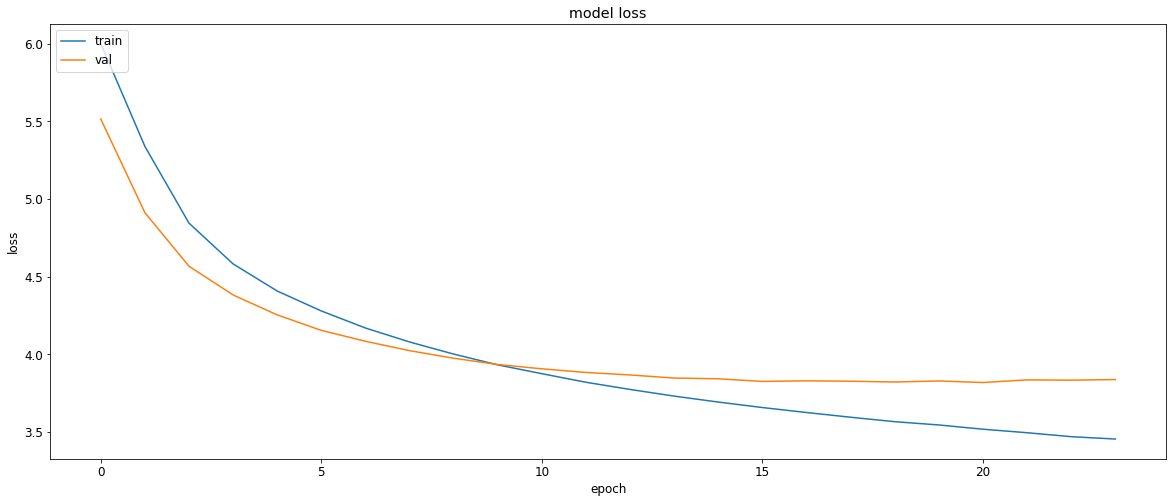

In [26]:
plt.figure(figsize=(20,8))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [27]:
def idx_to_word(integer,tokenizer):
    for word, index in tokenizer.word_index.items():
        if index==integer:
            return word
    return None

In [17]:
# def predict_caption(model, image, tokenizer, max_length, features):
#     feature = features[image]
#     in_text = "start"
#     for i in range(max_length):
#         sequence = tokenizer.texts_to_sequences([in_text])[0]
#         sequence = pad_sequences([sequence], max_length)

#         y_pred = model.predict([feature,sequence])
#         y_pred = np.argmax(y_pred)
        
#         word = idx_to_word(y_pred, tokenizer)
        
#         if word is None:
#             break
            
#         in_text+= " " + word
        
#         if word == "end":
#             break
            
#     return in_text 

In [28]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_caption_(model, image, tokenizer, max_length, features, temperature=1.0):
    """
    Generates a caption using Greedy Search but prevents word repetition.
    """
    feature = features[image].reshape((1, 1920))  # Ensure correct input shape
    in_text = ["start"]
    word_count = {}  # Dictionary to track word occurrences

    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding="post")

        y_pred = model.predict([feature, sequence], verbose=0)[0]

        # Apply temperature scaling for more diversity
        y_pred = np.exp(y_pred / temperature) / np.sum(np.exp(y_pred / temperature))

        # Select the most probable word
        y_pred_index = np.argmax(y_pred)

        word = idx_to_word(y_pred_index, tokenizer)
        if word is None:
            break

        # 🔹 Stop if word repeats too many times
        word_count[word] = word_count.get(word, 0) + 1
        if word_count[word] > 2:  # If a word appears more than twice, stop
            break

        in_text.append(word)
        if word == "end":
            break

    return " ".join(in_text[1:-1])  # Remove "start" and "end"

In [29]:
samples = test.sample(25)
samples.reset_index(drop=True,inplace=True)

In [31]:
for index,record in samples.iterrows():

    img = load_img(os.path.join(image_path,record['image']),target_size=(224,224))
    img = img_to_array(img)
    img = img/255.
    
    caption = predict_caption_(caption_model, record['image'], tokenizer, max_length, features)
    samples.loc[index,'caption'] = caption

2025-02-28 18:14:11.576310: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:689] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA RTX A5000" frequency: 1695 num_cores: 64 environment { key: "architecture" value: "8.6" } environment { key: "cuda" value: "11040" } environment { key: "cudnn" value: "8204" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 6291456 shared_memory_size_per_multiprocessor: 102400 memory_size: 23193059328 bandwidth: 768096000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


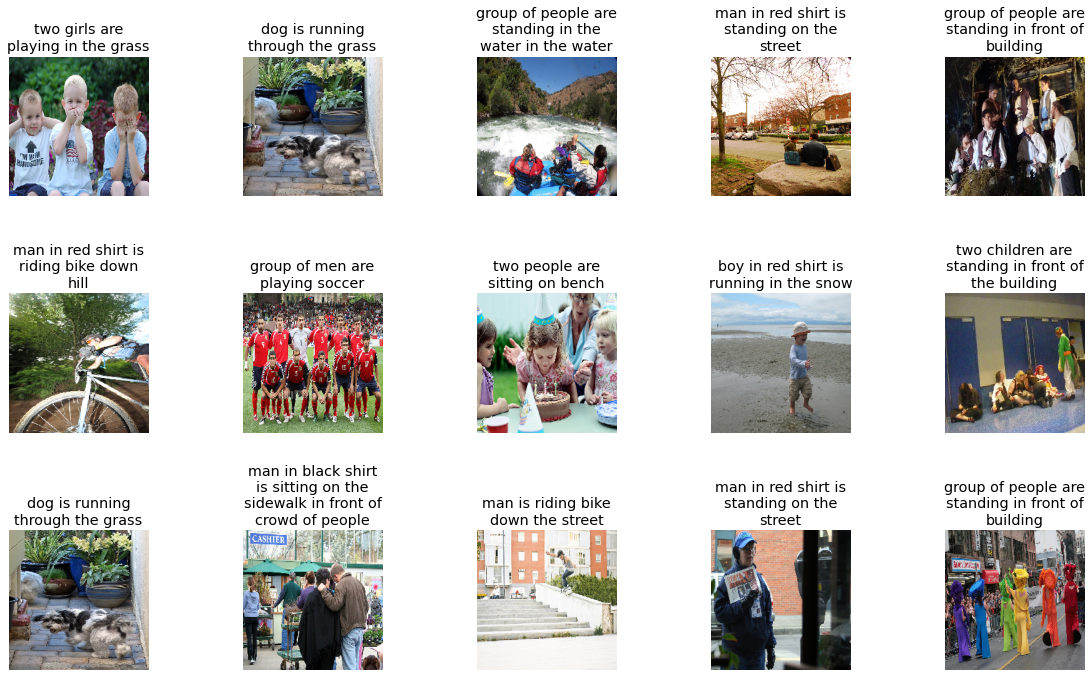

In [32]:
display_images(samples)

In [37]:
import numpy as np
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize

# Ensure NLTK resources are available
nltk.download('punkt')

# Function to compute BLEU score
def evaluate_bleu_score(model, tokenizer, features, test_data, max_length):
    print("\n🚀 Starting BLEU Score Evaluation...")

    individual_bleu_scores = []  # Store BLEU scores per image
    all_references = []  # Store reference captions for corpus BLEU
    all_hypotheses = []  # Store generated captions for corpus BLEU

    smoothing_function = SmoothingFunction().method1  # Smoothing for short captions

    # 🔹 Process each unique image only ONCE
    grouped_test_data = test_data.groupby("image")["caption"].apply(list).reset_index()

    for _, record in grouped_test_data.iterrows():
        image_name = record["image"]
        reference_captions = record["caption"]  # List of all reference captions for the image

        print(f"\n📷 Processing image: {image_name}")

        # 🔹 Generate Caption (Only Once Per Image)
        generated_caption = predict_caption_(model, image_name, tokenizer, max_length, features)
        print(f"🔹 Generated Caption: {generated_caption}")

        # 🔹 Tokenize Reference Captions & Generated Caption
        reference_tokens = [tokenize_text(ref, tokenizer) for ref in reference_captions]
        generated_tokens = tokenize_text(generated_caption, tokenizer)


        # 🔹 Skip BLEU computation if reference captions are empty
        if not reference_tokens or not generated_tokens or len(generated_tokens) < 2:
            print(f"⚠ Skipping BLEU computation for {image_name} (empty or too short caption)")
            continue


        # 🔹 Compute BLEU Score for This Image
        
        bleu1 = sentence_bleu(reference_tokens, generated_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothing_function)
        bleu2 = sentence_bleu(reference_tokens, generated_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing_function)
        bleu3 = sentence_bleu(reference_tokens, generated_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing_function)
        bleu4 = sentence_bleu(reference_tokens, generated_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing_function)

        print(f"🔹 BLEU-1: {bleu1:.4f} | BLEU-2: {bleu2:.4f} | BLEU-3: {bleu3:.4f} | BLEU-4: {bleu4:.4f}")


        individual_bleu_scores.append(bleu1)
        all_references.append(reference_tokens)
        all_hypotheses.append(generated_tokens)

    # 🔹 Compute Final Corpus BLEU Score
    corpus_bleu_score = corpus_bleu(all_references, all_hypotheses, smoothing_function=smoothing_function)

    print(f"\n📊 BLEU Score Summary:")
    print(f"🔹 Mean BLEU Score: {np.mean(individual_bleu_scores):.4f}")
    print(f"🔹 Median BLEU Score: {np.median(individual_bleu_scores):.4f}")
    print(f"🏆 Final Corpus BLEU Score: {corpus_bleu_score:.4f}")


    return corpus_bleu_score

# Run BLEU Score Evaluation (Only Once Per Image)
bleu_score = evaluate_bleu_score(caption_model, tokenizer, features, test, max_length)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!



🚀 Starting BLEU Score Evaluation...

📷 Processing image: 3601803640_5f3cb05acf.jpg
🔹 Generated Caption: two people are sitting on the street
🔹 BLEU-1: 0.5714 | BLEU-2: 0.3086 | BLEU-3: 0.1266 | BLEU-4: 0.0831

📷 Processing image: 3601843201_4809e66909.jpg
🔹 Generated Caption: the motorcycle rider is riding the motorcycle
🔹 BLEU-1: 0.5714 | BLEU-2: 0.3086 | BLEU-3: 0.1266 | BLEU-4: 0.0831

📷 Processing image: 3601978895_9fec23ce0c.jpg
🔹 Generated Caption: man in red shirt is standing in front of the building
🔹 BLEU-1: 0.5455 | BLEU-2: 0.0739 | BLEU-3: 0.0406 | BLEU-4: 0.0295

📷 Processing image: 3602676311_824b2c04ba.jpg
🔹 Generated Caption: man is riding bike on the street
🔹 BLEU-1: 0.7143 | BLEU-2: 0.1091 | BLEU-3: 0.0637 | BLEU-4: 0.0494

📷 Processing image: 3602838407_bf13e49243.jpg
🔹 Generated Caption: two dogs are running through the water
🔹 BLEU-1: 0.2857 | BLEU-2: 0.2182 | BLEU-3: 0.1007 | BLEU-4: 0.0699

📷 Processing image: 3603064161_a8f3b6455d.jpg
🔹 Generated Caption: young 

🔹 Generated Caption: man in red shirt and white shirt and
🔹 BLEU-1: 0.1250 | BLEU-2: 0.0423 | BLEU-3: 0.0321 | BLEU-4: 0.0278

📷 Processing image: 3611672054_45edd3e08f.jpg
🔹 Generated Caption: boy in blue shirt is running in the snow
🔹 BLEU-1: 0.3559 | BLEU-2: 0.1887 | BLEU-3: 0.0759 | BLEU-4: 0.0483

📷 Processing image: 361183669_52be9662b9.jpg
🔹 Generated Caption: man in blue shirt is standing in the
🔹 BLEU-1: 0.2500 | BLEU-2: 0.0598 | BLEU-3: 0.0403 | BLEU-4: 0.0330

📷 Processing image: 3612249030_e2829ffa31.jpg
🔹 Generated Caption: woman in blue shirt and hat is standing in front of the background
🔹 BLEU-1: 0.3846 | BLEU-2: 0.0566 | BLEU-3: 0.0319 | BLEU-4: 0.0232

📷 Processing image: 3612484827_0e479f9ee8.jpg
🔹 Generated Caption: man in red shirt is jumping on the air
🔹 BLEU-1: 0.5556 | BLEU-2: 0.2635 | BLEU-3: 0.1021 | BLEU-4: 0.0638

📷 Processing image: 3612485097_b706d950ed.jpg
🔹 Generated Caption: man in red shirt is standing in front of the street
🔹 BLEU-1: 0.4545 | BLEU-2: 

🔹 Generated Caption: man in red shirt is riding bike down the street
🔹 BLEU-1: 0.3000 | BLEU-2: 0.0577 | BLEU-3: 0.0359 | BLEU-4: 0.0278

📷 Processing image: 3621329299_6fb3f2935c.jpg
🔹 Generated Caption: man in red shirt is riding bike down hill
🔹 BLEU-1: 0.4971 | BLEU-2: 0.2358 | BLEU-3: 0.0913 | BLEU-4: 0.0571

📷 Processing image: 3621623690_0095e330bc.jpg
🔹 Generated Caption: man in blue shirt is riding on the sidewalk
🔹 BLEU-1: 0.4444 | BLEU-2: 0.0745 | BLEU-3: 0.0443 | BLEU-4: 0.0339

📷 Processing image: 3621647714_fc67ab2617.jpg
🔹 Generated Caption: man is riding down snowy hill
🔹 BLEU-1: 0.5643 | BLEU-2: 0.4371 | BLEU-3: 0.1620 | BLEU-4: 0.1034

📷 Processing image: 3621649810_cca783b777.jpg
🔹 Generated Caption: man in blue shorts is standing in the
🔹 BLEU-1: 0.3436 | BLEU-2: 0.1837 | BLEU-3: 0.0745 | BLEU-4: 0.0480

📷 Processing image: 3621652774_fd9634bd5b.jpg
🔹 Generated Caption: boy in blue bathing suit is jumping into the water
🔹 BLEU-1: 0.5000 | BLEU-2: 0.2357 | BLEU-3: 0.

🔹 Generated Caption: group of people are standing in front of the building
🔹 BLEU-1: 0.4094 | BLEU-2: 0.3342 | BLEU-3: 0.2869 | BLEU-4: 0.2274

📷 Processing image: 3631671718_d712821757.jpg
🔹 Generated Caption: young girl in red shirt is running in the grass
🔹 BLEU-1: 0.5000 | BLEU-2: 0.3333 | BLEU-3: 0.2438 | BLEU-4: 0.1187

📷 Processing image: 3631810528_7233c0f421.jpg
🔹 Generated Caption: group of people are standing on the street
🔹 BLEU-1: 0.5516 | BLEU-2: 0.3729 | BLEU-3: 0.1294 | BLEU-4: 0.0775

📷 Processing image: 3631986552_944ea208fc.jpg
🔹 Generated Caption: the surfer is jumping into the water
🔹 BLEU-1: 0.4286 | BLEU-2: 0.2673 | BLEU-3: 0.1151 | BLEU-4: 0.0773

📷 Processing image: 3632047678_f202609e50.jpg
🔹 Generated Caption: two children are standing in front of the building
🔹 BLEU-1: 0.4444 | BLEU-2: 0.0745 | BLEU-3: 0.0443 | BLEU-4: 0.0339

📷 Processing image: 3632197966_0c5061025f.jpg
🔹 Generated Caption: man in red shirt is riding bike down dirt road
🔹 BLEU-1: 0.2000 | 

...

🔹 Generated Caption: two women are sitting on the floor
🔹 BLEU-1: 0.2857 | BLEU-2: 0.2182 | BLEU-3: 0.1007 | BLEU-4: 0.0699

📷 Processing image: 758921886_55a351dd67.jpg
🔹 Generated Caption: young girl in blue shirt is standing in front of the building
🔹 BLEU-1: 0.4167 | BLEU-2: 0.2752 | BLEU-3: 0.1996 | BLEU-4: 0.0958

📷 Processing image: 759015118_4bd3617e60.jpg
🔹 Generated Caption: young girl in blue shirt is standing in front of the water
🔹 BLEU-1: 0.5000 | BLEU-2: 0.3015 | BLEU-3: 0.2120 | BLEU-4: 0.1003

📷 Processing image: 760138567_762d9022d4.jpg
🔹 Generated Caption: man in blue shirt is jumping into pool
🔹 BLEU-1: 0.7500 | BLEU-2: 0.6547 | BLEU-3: 0.5262 | BLEU-4: 0.4111

📷 Processing image: 760180310_3c6bd4fd1f.jpg
🔹 Generated Caption: two dogs are running in the grass
🔹 BLEU-1: 0.1212 | BLEU-2: 0.0293 | BLEU-3: 0.0200 | BLEU-4: 0.0167

📷 Processing image: 762947607_2001ee4c72.jpg
🔹 Generated Caption: little girl in red shirt is running in the grass
🔹 BLEU-1: 0.7000 | BLEU-2:

🔹 Generated Caption: two girls are playing in the grass
🔹 BLEU-1: 0.5714 | BLEU-2: 0.4364 | BLEU-3: 0.3402 | BLEU-4: 0.1757

📷 Processing image: 822836318_21544f0f78.jpg
🔹 Generated Caption: man in red jacket is riding down the snow
🔹 BLEU-1: 0.5556 | BLEU-2: 0.0833 | BLEU-3: 0.0477 | BLEU-4: 0.0359

📷 Processing image: 823675317_b5fbdb17b3.jpg
🔹 Generated Caption: young girl in red shirt is running through the snow
🔹 BLEU-1: 0.4000 | BLEU-2: 0.0667 | BLEU-3: 0.0394 | BLEU-4: 0.0298

📷 Processing image: 823697339_aadbeef495.jpg
🔹 Generated Caption: man in red shirt and white shirt is sitting on the street
🔹 BLEU-1: 0.2500 | BLEU-2: 0.0477 | BLEU-3: 0.0294 | BLEU-4: 0.0224

📷 Processing image: 824123145_59243e504e.jpg
🔹 Generated Caption: two children are playing in the grass
🔹 BLEU-1: 0.3715 | BLEU-2: 0.0733 | BLEU-3: 0.0467 | BLEU-4: 0.0377

📷 Processing image: 824782868_a8f532f3a6.jpg
🔹 Generated Caption: woman in red shirt and white shirt is standing in the grass
🔹 BLEU-1: 0.4167 | 

🔹 Generated Caption: group of people are standing in front of the building
🔹 BLEU-1: 0.5186 | BLEU-2: 0.3578 | BLEU-3: 0.2307 | BLEU-4: 0.1058

📷 Processing image: 872622575_ba1d3632cc.jpg
🔹 Generated Caption: man is standing on the beach
🔹 BLEU-1: 0.5000 | BLEU-2: 0.3162 | BLEU-3: 0.1385 | BLEU-4: 0.0955

📷 Processing image: 873633312_a756d8b381.jpg
🔹 Generated Caption: boy in blue shirt is jumping into the air
🔹 BLEU-1: 0.5966 | BLEU-2: 0.4474 | BLEU-3: 0.2980 | BLEU-4: 0.1398

📷 Processing image: 874665322_9ad05c4065.jpg
🔹 Generated Caption: dog is running through the grass
🔹 BLEU-1: 0.7054 | BLEU-2: 0.5986 | BLEU-3: 0.4262 | BLEU-4: 0.2151

📷 Processing image: 875731481_a5a0a09934.jpg
🔹 Generated Caption: woman in red shirt and white shirt and
🔹 BLEU-1: 0.2500 | BLEU-2: 0.0598 | BLEU-3: 0.0403 | BLEU-4: 0.0330

📷 Processing image: 878758390_dd2cdc42f6.jpg
🔹 Generated Caption: dog is running through the snow
🔹 BLEU-1: 0.5643 | BLEU-2: 0.4371 | BLEU-3: 0.3463 | BLEU-4: 0.1838

📷 Proc

🔹 Generated Caption: dog is running through the water
🔹 BLEU-1: 0.2453 | BLEU-2: 0.1900 | BLEU-3: 0.0704 | BLEU-4: 0.0449

📷 Processing image: 948196883_e190a483b1.jpg
🔹 Generated Caption: two children are standing in front of the building
🔹 BLEU-1: 0.3981 | BLEU-2: 0.2670 | BLEU-3: 0.1965 | BLEU-4: 0.0966

📷 Processing image: 950273886_88c324e663.jpg
🔹 Generated Caption: man in blue shirt is standing in the water
🔹 BLEU-1: 0.4444 | BLEU-2: 0.2357 | BLEU-3: 0.0948 | BLEU-4: 0.0603

📷 Processing image: 950411653_20d0335946.jpg
🔹 Generated Caption: two children are playing in pool
🔹 BLEU-1: 0.2822 | BLEU-2: 0.0691 | BLEU-3: 0.0480 | BLEU-4: 0.0411

📷 Processing image: 95151149_5ca6747df6.jpg
🔹 Generated Caption: man is riding down snowy hill
🔹 BLEU-1: 0.3333 | BLEU-2: 0.0816 | BLEU-3: 0.0567 | BLEU-4: 0.0485

📷 Processing image: 952171414_2db16f846f.jpg
🔹 Generated Caption: group of people are standing in front of building
🔹 BLEU-1: 0.7778 | BLEU-2: 0.5401 | BLEU-3: 0.3504 | BLEU-4: 0.16

🔹 Generated Caption: two dogs run in the grass
🔹 BLEU-1: 0.4044 | BLEU-2: 0.3132 | BLEU-3: 0.1161 | BLEU-4: 0.0741

📷 Processing image: 989754491_7e53fb4586.jpg
🔹 Generated Caption: two children are playing in pool
🔹 BLEU-1: 0.2453 | BLEU-2: 0.1900 | BLEU-3: 0.0704 | BLEU-4: 0.0449

📷 Processing image: 989851184_9ef368e520.jpg
🔹 Generated Caption: two girls are playing in the grass
🔹 BLEU-1: 0.2147 | BLEU-2: 0.0519 | BLEU-3: 0.0354 | BLEU-4: 0.0295

📷 Processing image: 990890291_afc72be141.jpg
🔹 Generated Caption: man in red shirt is riding bike on the street
🔹 BLEU-1: 0.7000 | BLEU-2: 0.3944 | BLEU-3: 0.1274 | BLEU-4: 0.0726

📷 Processing image: 99171998_7cc800ceef.jpg
🔹 Generated Caption: group of people are standing in front of the trees
🔹 BLEU-1: 0.6000 | BLEU-2: 0.4472 | BLEU-3: 0.2960 | BLEU-4: 0.1375

📷 Processing image: 99679241_adc853a5c0.jpg
🔹 Generated Caption: the bird is jumping over the water
🔹 BLEU-1: 0.4653 | BLEU-2: 0.3179 | BLEU-3: 0.1116 | BLEU-4: 0.0680

📷 Processin

NameError: name 'caption_model' is not defined

In [40]:
!pip install gradio

You should consider upgrading via the '/usr/bin/python -m pip install --upgrade pip' command.


In [41]:
import gradio as gr
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os

# Load the trained model
caption_model = tf.keras.models.load_model("model.keras")

# Load tokenizer and features
import pickle
with open("tokenizer.pkl", "rb") as handle:
    tokenizer = pickle.load(handle)

with open("features.pkl", "rb") as handle:
    features = pickle.load(handle)

max_length = 34  # Set this to the max length used during training

# Gradio Interface
def generate_caption(image):
    image_path = "temp_image.jpg"
    image.save(image_path)
    caption = predict_caption(image_path)
    return caption

interface = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Image Captioning Model",
    description="Upload an image, and the model will generate a caption for it!"
)

if __name__ == "__main__":
    interface.launch()

FileNotFoundError: [Errno 2] No such file or directory: 'tokenizer.pkl'

In [42]:
caption_model.save("model1.h5")

In [9]:
from tensorflow.keras.models import load_model

model = load_model('/LAB/Image Captioning/model.h5')

In [40]:
pip install --upgrade typing_extensions


You should consider upgrading via the '/usr/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [38]:
pip install gradio==3.50.2


     |████████████████████████████████| 20.3 MB 5.7 MB/s eta 0:00:01
     |████████████████████████████████| 299 kB 5.5 MB/s eta 0:00:01
     |████████████████████████████████| 658 kB 5.6 MB/s eta 0:00:01
     |████████████████████████████████| 308 kB 5.9 MB/s eta 0:00:01
  Attempting uninstall: gradio-client
    Found existing installation: gradio-client 1.3.0
    Uninstalling gradio-client-1.3.0:
      Successfully uninstalled gradio-client-1.3.0
  Attempting uninstall: gradio
    Found existing installation: gradio 4.44.1


    Uninstalling gradio-4.44.1:
      Successfully uninstalled gradio-4.44.1
You should consider upgrading via the '/usr/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [41]:
import gradio as gr
print(gr.__version__)


ImportError: cannot import name 'NotRequired' from 'typing_extensions' (/usr/local/lib/python3.8/dist-packages/typing_extensions.py)

In [43]:
!nvidia-smi

Fri Feb 28 18:32:41 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.256.02   Driver Version: 470.256.02   CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A5000    Off  | 00000000:3B:00.0 Off |                  Off |
| 31%   59C    P8    22W / 230W |  23671MiB / 24256MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A5000    Off  | 00000000:AF:00.0 Off |                  Off |
| 30%   